In [1]:
!pip install circlify

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import circlify
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体  
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

## 一层

In [89]:
df = pd.DataFrame({
    'Name': ['A', 'B', 'C', 'D', 'E', 'F'],
    'Value': [10, 2, 23, 87, 12, 65]
})

In [91]:
# compute circle positions
circles = circlify.circlify(
    df['Value'].tolist(),
    show_enclosure=False,
    target_enclosure=circlify.Circle(x=0, y=0, r=1)
)

# reverse the order of the circles to match the order of data
circles = circles[::-1]

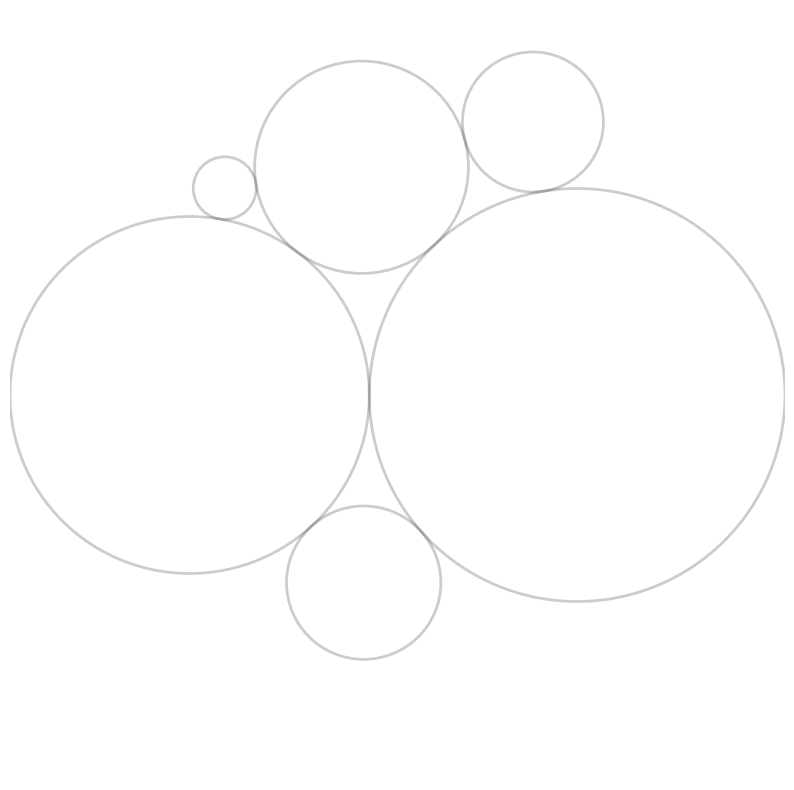

In [93]:
# 创建一个图形和一个子图
fig, ax = plt.subplots(figsize=(10, 10))

# 隐藏坐标轴
ax.set_axis_off()

# 计算坐标轴的边界值
limit = max(
    max(
        abs(c.x) + c.r,
        abs(c.y) + c.r,
    )
    for c in circles
)
# 设置x和y轴的显示范围
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)

# 绘制所有的圆
for c in circles:
    x, y, r = c
    circle_patch = plt.Circle((x, y), r, alpha=0.2, linewidth=2, fill=False)
    ax.add_patch(circle_patch)


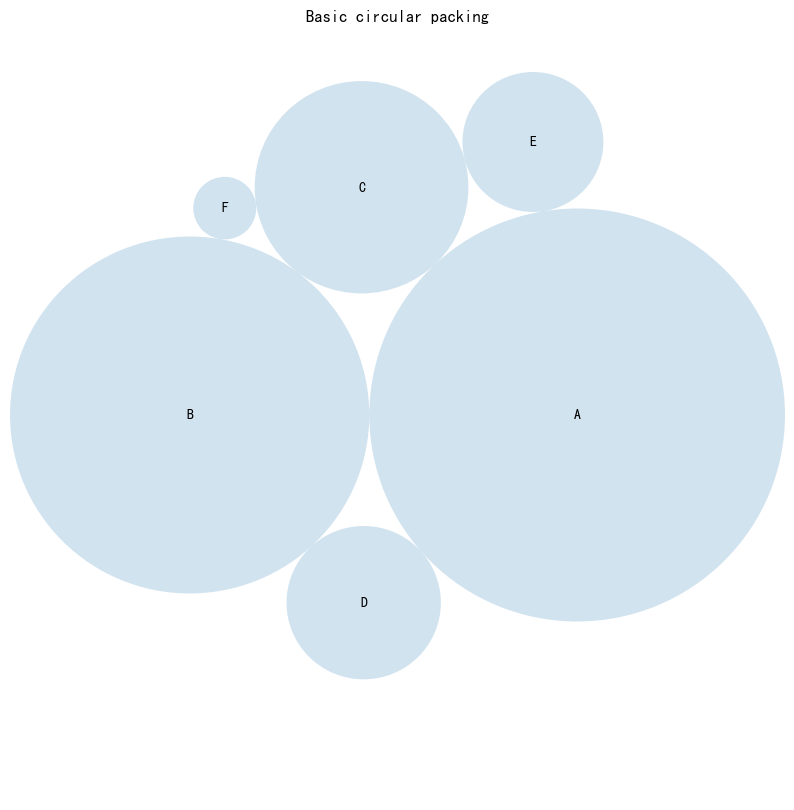

In [95]:
# 创建图形和子图
fig, ax = plt.subplots(figsize=(10, 10))

# 设置标题
ax.set_title('Basic circular packing')

# 移除坐标轴
ax.axis('off')

# 计算轴的边界
def calculate_lim(circles):
    return max(
        abs(circle.x) + circle.r
        for circle in circles
    )

lim = calculate_lim(circles)
plt.xlim(-lim, lim)
plt.ylim(-lim, lim)

# 标签列表
labels = df['Name']

# 绘制圆和标签
def add_circle_and_label(ax, circle, label):
    x, y, r = circle
    ax.add_patch(plt.Circle((x, y), r, alpha=0.2, linewidth=2))
    plt.annotate(label, (x, y), va='center', ha='center')

# 遍历绘制所有圆形和标签
for circle, label in zip(circles, labels):
    add_circle_and_label(ax, circle, label)


## 调整间隙

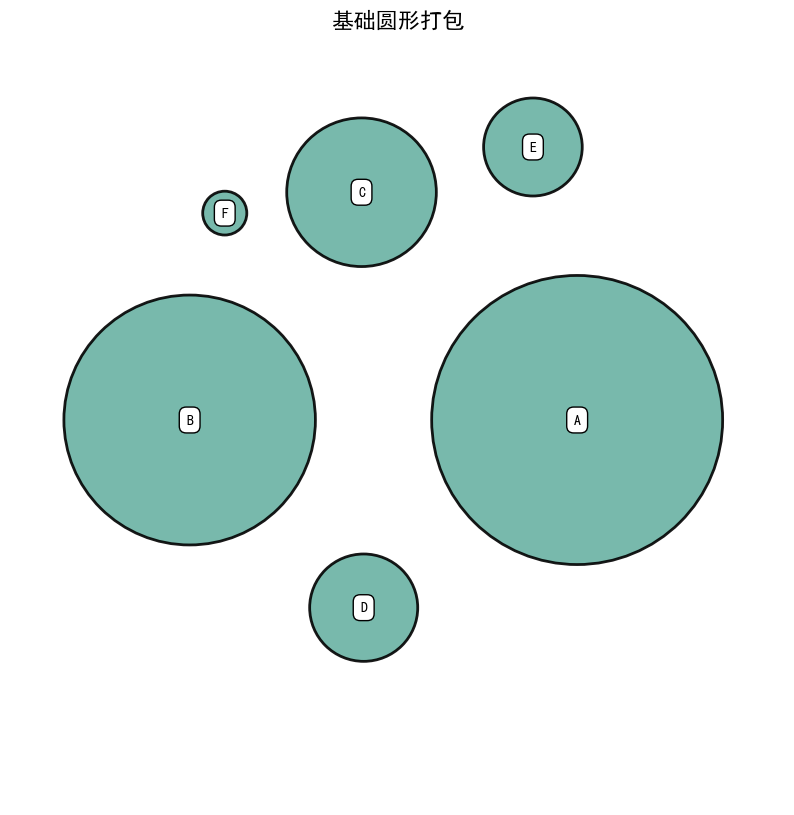

In [97]:
# 创建图形和一个子图
fig, ax = plt.subplots(figsize=(10, 10))

# 设置标题
ax.set_title('基础圆形打包', fontsize=16)

# 隐藏坐标轴
ax.set_axis_off()

# 计算坐标轴的边界范围
boundary_limit = max(
    max(
        abs(c.x) + c.r,
        abs(c.y) + c.r,
    )
    for c in circles
)

# 设置x和y轴的范围
ax.set_xlim(-boundary_limit, boundary_limit)
ax.set_ylim(-boundary_limit, boundary_limit)

# 获取标签列表
circle_labels = df['Name']

# 绘制圆形和标签
for c, lbl in zip(circles, circle_labels):
    x, y, r = c
    # 添加圆形补丁
    circle_obj = plt.Circle((x, y), r*0.7, alpha=0.9, linewidth=2, 
                            facecolor="#69b2a3", edgecolor="black")
    ax.add_patch(circle_obj)
    # 添加标签
    ax.annotate(lbl, (x, y), va='center', ha='center', bbox=dict(
        facecolor='white', edgecolor='black', boxstyle='round', pad=0.5))
plt.savefig('jianju.png', dpi=300)

## 多层

In [26]:
data = [{'id': 'World', 'datum': 6964195249, 'children': [
    {'id': "North America", 'datum': 450448697,
               'children': [
                   {'id': "United States", 'datum': 308865000},
                   {'id': "Mexico", 'datum': 107550697},
                   {'id': "Canada", 'datum': 34033000}
               ]},
    {'id': "South America", 'datum': 278095425,
     'children': [
         {'id': "Brazil", 'datum': 192612000},
         {'id': "Colombia", 'datum': 45349000},
         {'id': "Argentina", 'datum': 40134425}
     ]},
    {'id': "Europe", 'datum': 209246682,
     'children': [
         {'id': "Germany", 'datum': 81757600},
         {'id': "France", 'datum': 65447374},
         {'id': "United Kingdom", 'datum': 62041708}
     ]},
    {'id': "Africa", 'datum': 311929000,
     'children': [
         {'id': "Nigeria", 'datum': 154729000},
         {'id': "Ethiopia", 'datum': 79221000},
         {'id': "Egypt", 'datum': 77979000}
     ]},
    {'id': "Asia", 'datum': 2745929500,
     'children': [
                   {'id': "China", 'datum': 1336335000},
                   {'id': "India", 'datum': 1178225000},
                   {'id': "Indonesia", 'datum': 231369500}
     ]}
]}]

In [32]:
# 使用 circlify() 函数计算圆的位置信息
circle_positions = circlify.circlify(
    data,                     # 输入数据
    show_enclosure=False,      # 不显示外包圆
    target_enclosure=circlify.Circle(x=0, y=0, r=1)  # 设置目标包围圆的大小和位置
)

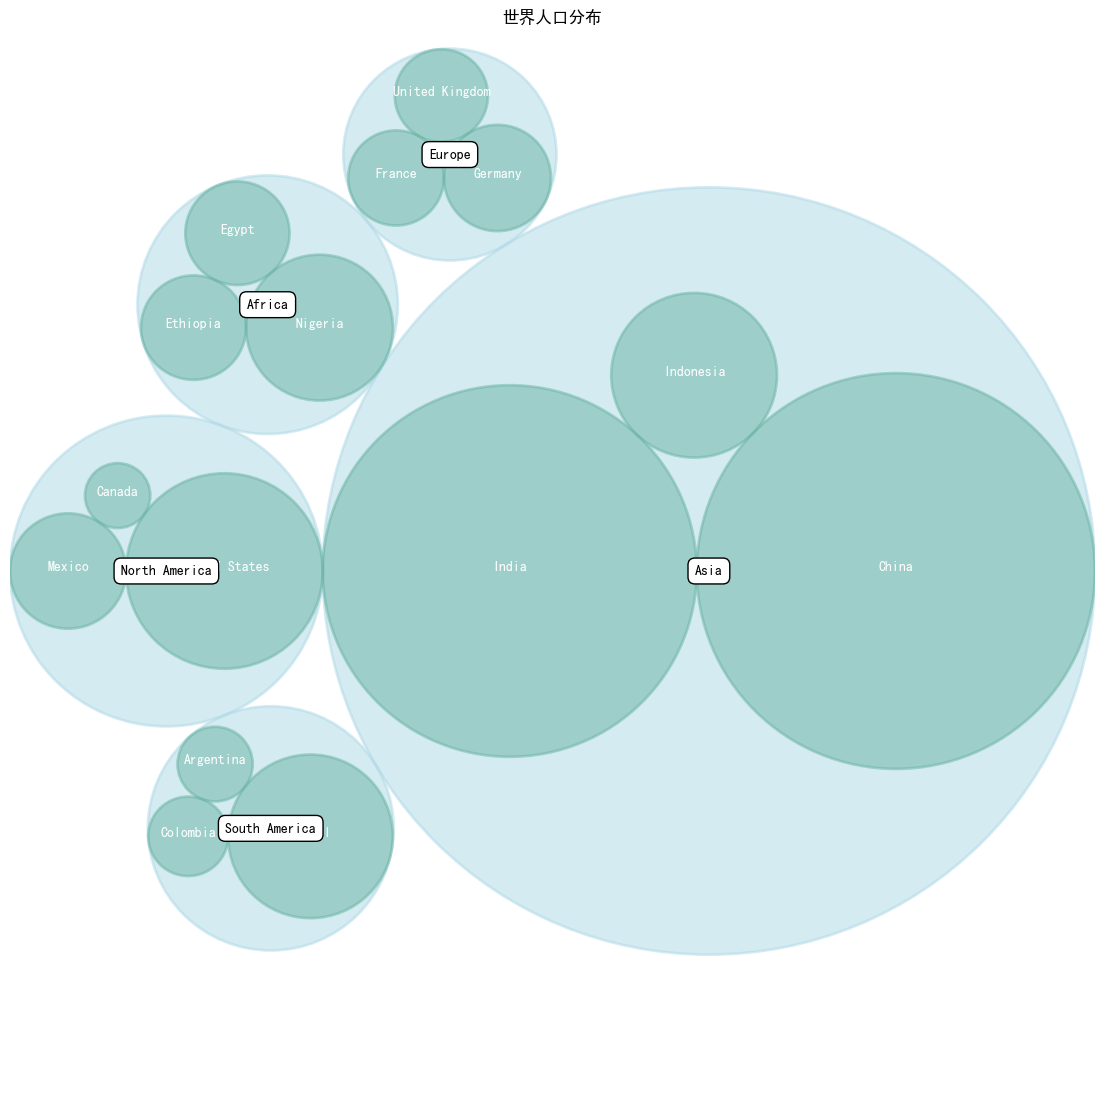

In [62]:
# 创建图形和一个子图
fig, ax = plt.subplots(figsize=(14, 14))

# 设置标题
ax.set_title('世界人口分布')

# 隐藏坐标轴
ax.set_axis_off()

# 计算坐标轴的边界值
boundary_limit = max(
    max(
        abs(c.x) + c.r,
        abs(c.y) + c.r,
    )
    for c in circle_positions
)

# 设置x和y轴的显示范围
ax.set_xlim(-boundary_limit, boundary_limit)
ax.set_ylim(-boundary_limit, boundary_limit)

# 绘制最高级别的圆（洲级别）
for c in circle_positions:
    if c.level != 2:
        continue
    x, y, r = c
    ax.add_patch(plt.Circle((x, y), r, alpha=0.5,
                            linewidth=2, color="lightblue"))

# 绘制和标记次高级别的圆（国家级别）
for c in circle_positions:
    if c.level != 3:
        continue
    x, y, r = c
    label = c.ex["id"]
    ax.add_patch(plt.Circle((x, y), r, alpha=0.5,
                            linewidth=2, color="#69b3a2"))
    plt.annotate(label, (x, y), ha='center', color="white")

# 为洲级别的圆添加标签
for c in circle_positions:
    if c.level != 2:
        continue
    x, y, r = c
    label = c.ex["id"]
    plt.annotate(label, (x, y), va='center', ha='center', bbox=dict(
        facecolor='white', edgecolor='black', boxstyle='round', pad=0.5))
plt.savefig('人口.png', dpi=300)

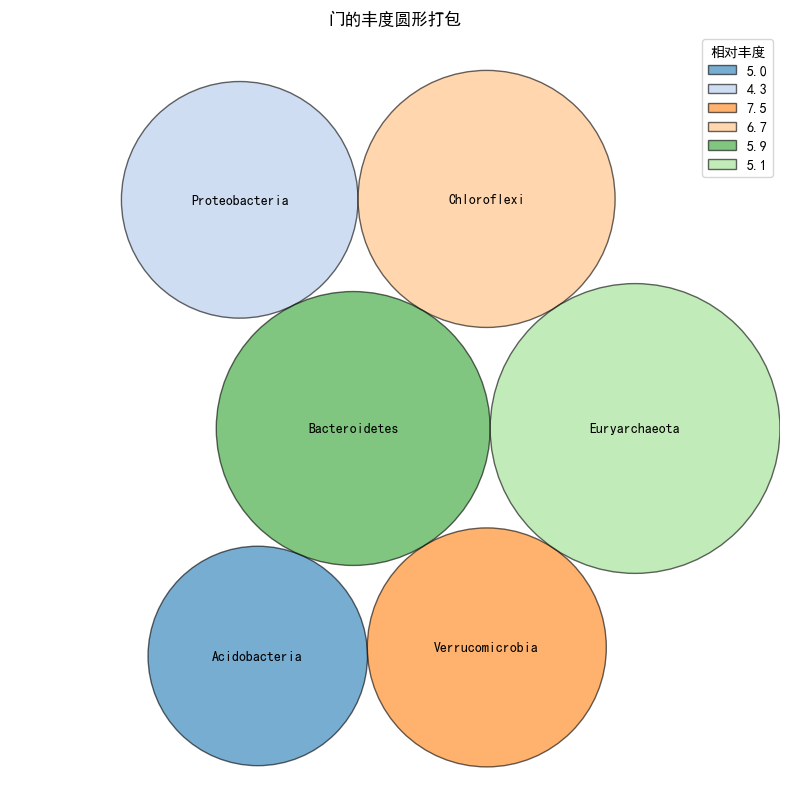

In [64]:
import matplotlib.pyplot as plt
import circlify
import random

# 示例数据，表示相对丰度和相应的标签
data = [
    ('Acidobacteria', 5.0),
    ('Proteobacteria', 4.3),
    ('Verrucomicrobia', 7.5),
    ('Chloroflexi', 6.7),
    ('Bacteroidetes', 5.9),
    ('Euryarchaeota', 5.1)
]

# 从数据中提取标签和数值
labels = [item[0] for item in data]
sizes = [item[1] for item in data]

# 使用 circlify 计算圆的位置
circles = circlify.circlify(sizes, show_enclosure=False, target_enclosure=circlify.Circle(x=0, y=0, r=1))

# 创建一个新的图形和坐标轴
fig, ax = plt.subplots(figsize=(10, 10))

# 隐藏坐标轴
ax.axis('off')

# 找到边界以确保圆形能适当地显示
lim = max(
    max(abs(circle.x) + circle.r, abs(circle.y) + circle.r)
    for circle in circles
)

# 设置坐标轴的显示范围和长宽比
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal')

# 定义颜色列表
colors = plt.cm.tab20.colors  # 使用 'tab20' 颜色方案

# 绘制圆形
for i, (circle, label) in enumerate(zip(circles, labels)):
    x, y, r = circle
    color = colors[i % len(colors)]  # 根据索引选择颜色
    ax.add_patch(plt.Circle((x, y), r, alpha=0.6, edgecolor="black", facecolor=color))  # 添加颜色
    plt.annotate(label, (x, y), ha='center', va='center', color='black')

# 相对丰度的图例
legend_labels = [f'{value}' for value in sizes]
plt.legend(legend_labels, title="相对丰度", loc='upper right')

# 显示图形
plt.title("门的丰度圆形打包")
plt.savefig('fenlei.png', dpi=300)
plt.show()


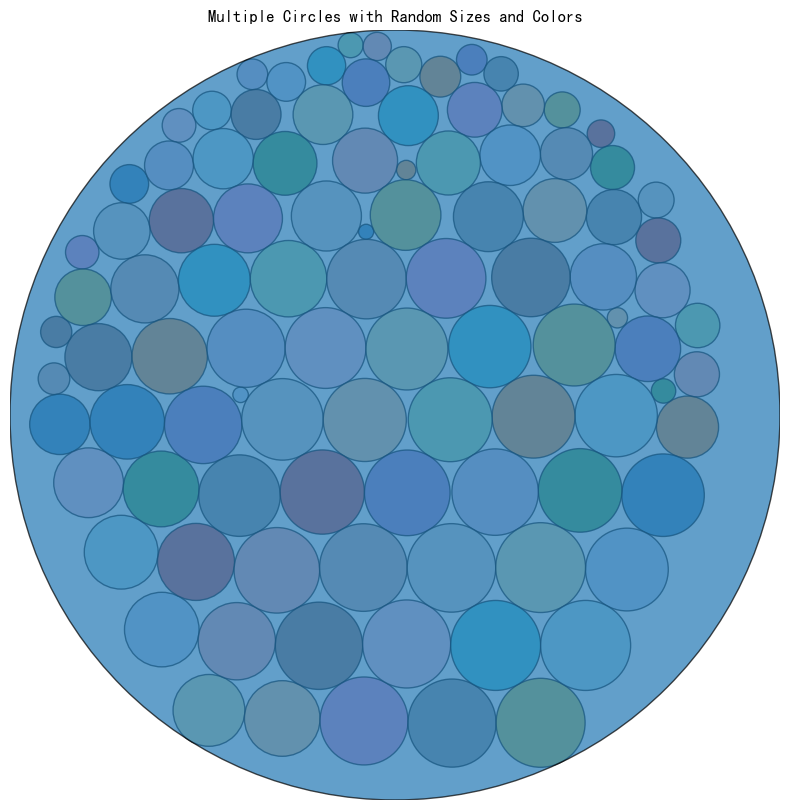

In [66]:
import matplotlib.pyplot as plt
import circlify
import random

# 生成一些随机的数据，表示不同圆的相对大小
num_circles = 100
data = [random.uniform(0.1, 10) for _ in range(num_circles)]

# 计算圆的位置
circles = circlify.circlify(data, show_enclosure=True, target_enclosure=circlify.Circle(x=0, y=0, r=1))

# 创建一个新的 figure 和 axis
fig, ax = plt.subplots(figsize=(10, 10))

# 隐藏坐标轴
ax.axis('off')

# 找到边界以确保所有圆形能正确显示
lim = max(
    max(abs(circle.x) + circle.r, abs(circle.y) + circle.r)
    for circle in circles
)

# 设置坐标轴的显示范围
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal')

# 定义颜色映射，使用 'tab20' 配色方案
colors = plt.colormaps['tab20'].colors  # 这是一个颜色列表

# 绘制所有圆形
for i, circle in enumerate(circles):
    x, y, r = circle
    color = colors[i % len(colors)]  # 使用颜色列表中的颜色
    ax.add_patch(plt.Circle((x, y), r, facecolor=color, alpha=0.7, edgecolor='black'))

# 显示图形
plt.title('Multiple Circles with Random Sizes and Colors')
plt.savefig('mutil1.png', dpi=300)
plt.show()


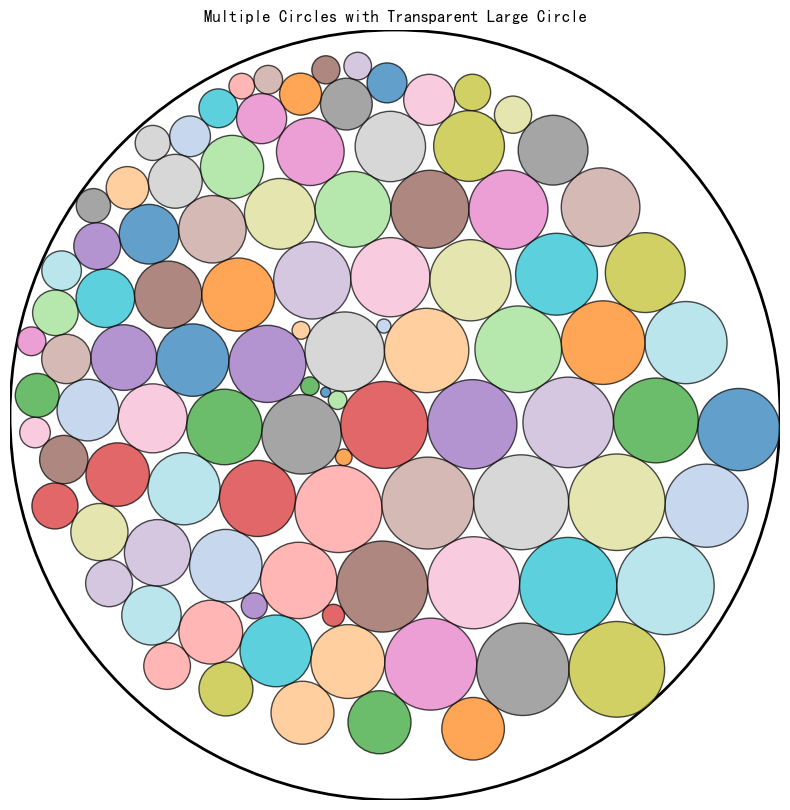

In [68]:
import matplotlib.pyplot as plt
import circlify
import random

# 生成一些随机的数据，表示不同圆的相对大小
num_circles = 100
data = [random.uniform(0.1, 10) for _ in range(num_circles)]

# 计算圆的位置，target_enclosure 设置为隐含的大圆
circles = circlify.circlify(data, show_enclosure=False, target_enclosure=circlify.Circle(x=0, y=0, r=1))

# 创建一个新的 figure 和 axis
fig, ax = plt.subplots(figsize=(10, 10))

# 隐藏坐标轴
ax.axis('off')

# 找到边界以确保所有圆形能正确显示
lim = max(
    max(abs(circle.x) + circle.r, abs(circle.y) + circle.r)
    for circle in circles
)

# 设置坐标轴的显示范围
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal')

# 手动添加大圆，并设置为无色填充
ax.add_patch(plt.Circle((0, 0), lim, facecolor='none', edgecolor='black', linewidth=2))  # 无色大圆

# 定义颜色映射，使用 'tab20' 配色方案
colors = plt.colormaps['tab20'].colors  # 这是一个颜色列表

# 绘制所有小圆形
for i, circle in enumerate(circles):
    x, y, r = circle
    color = colors[i % len(colors)]  # 使用颜色列表中的颜色
    ax.add_patch(plt.Circle((x, y), r, facecolor=color, alpha=0.7, edgecolor='black'))

# 显示图形
plt.title('Multiple Circles with Transparent Large Circle')
plt.savefig('mutil2.png', dpi=300)
plt.show()


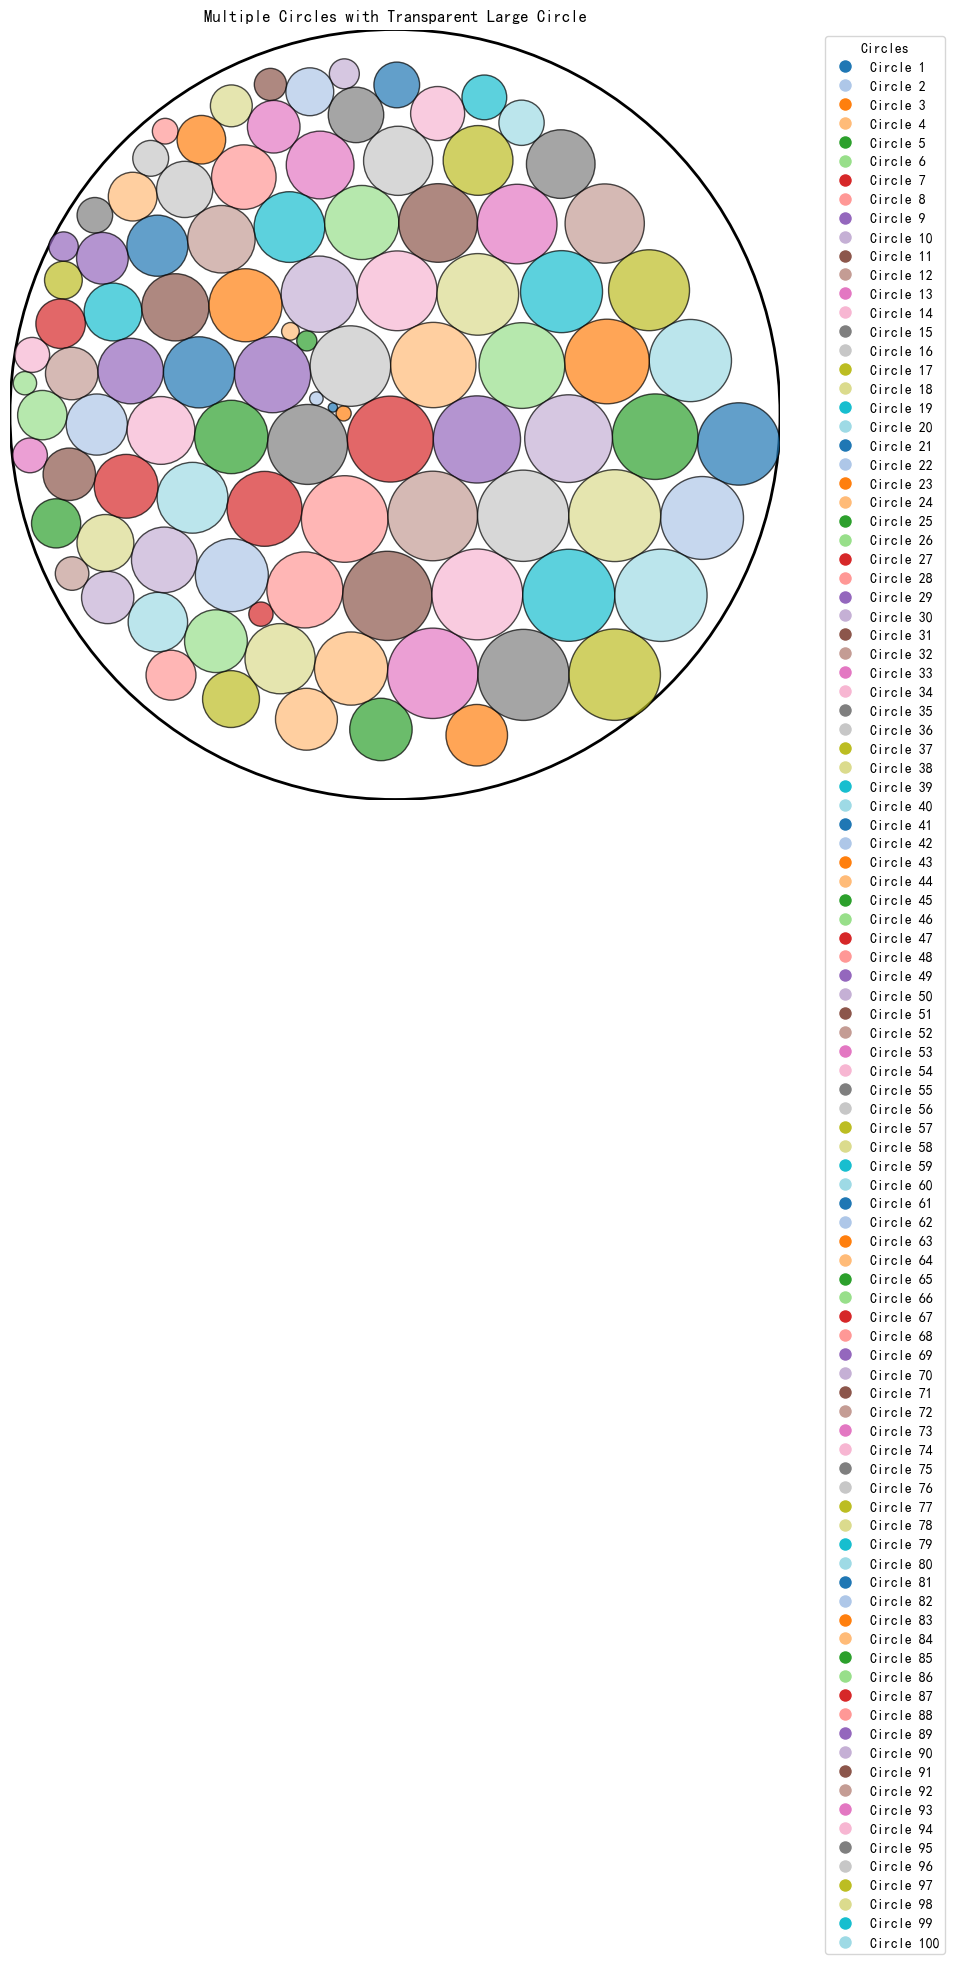

In [76]:
import matplotlib.pyplot as plt
import circlify
import random

# 生成一些随机的数据，表示不同圆的相对大小
num_circles = 100
data = [random.uniform(0.1, 10) for _ in range(num_circles)]

# 计算圆的位置，target_enclosure 设置为隐含的大圆
circles = circlify.circlify(data, show_enclosure=False, target_enclosure=circlify.Circle(x=0, y=0, r=1))

# 创建一个新的 figure 和 axis
fig, ax = plt.subplots(figsize=(10, 10))

# 隐藏坐标轴
ax.axis('off')

# 找到边界以确保所有圆形能正确显示
lim = max(
    max(abs(circle.x) + circle.r, abs(circle.y) + circle.r)
    for circle in circles
)

# 设置坐标轴的显示范围
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal')

# 手动添加大圆，并设置为无色填充
ax.add_patch(plt.Circle((0, 0), lim, facecolor='none', edgecolor='black', linewidth=2))  # 无色大圆

# 定义颜色映射，使用 'tab20' 配色方案
colors = plt.colormaps['tab20'].colors  # 这是一个颜色列表

# 绘制所有小圆形
labels = []  # 用于保存标签
for i, circle in enumerate(circles):
    x, y, r = circle
    color = colors[i % len(colors)]  # 使用颜色列表中的颜色
    circle_patch = plt.Circle((x, y), r, facecolor=color, alpha=0.7, edgecolor='black')
    ax.add_patch(circle_patch)
    
    # 添加标签
    labels.append(f'Circle {i + 1}')

# 创建图例
handles = [plt.Line2D([0], [0], marker='o', color='w', label=labels[i], 
                       markerfacecolor=colors[i % len(colors)], markersize=10) for i in range(num_circles)]
ax.legend(handles=handles, title='Circles', bbox_to_anchor=(1.05, 1), loc='upper left')

# 显示图形
plt.title('Multiple Circles with Transparent Large Circle')
plt.savefig('mutil3.png', dpi=300, bbox_inches='tight')
plt.show()

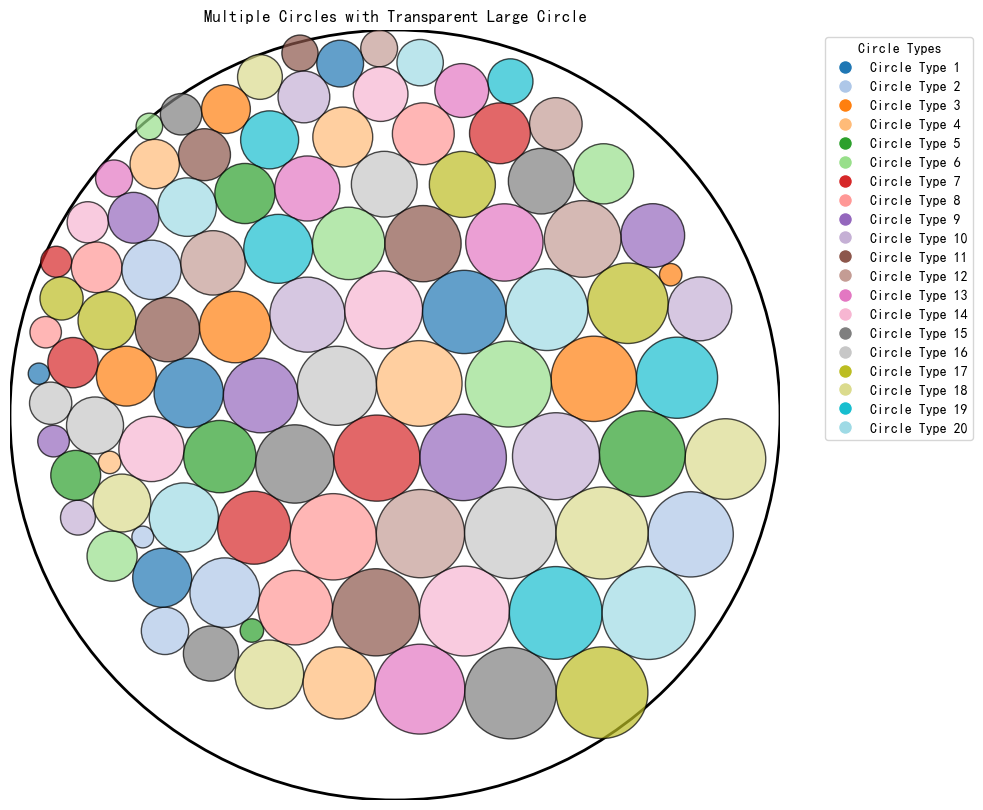

In [74]:
import matplotlib.pyplot as plt
import circlify
import random

# 生成一些随机的数据，表示不同圆的相对大小
num_circles = 100
data = [random.uniform(0.1, 10) for _ in range(num_circles)]

# 计算圆的位置，target_enclosure 设置为隐含的大圆
circles = circlify.circlify(data, show_enclosure=False, target_enclosure=circlify.Circle(x=0, y=0, r=1))

# 创建一个新的 figure 和 axis
fig, ax = plt.subplots(figsize=(10, 10))

# 隐藏坐标轴
ax.axis('off')

# 找到边界以确保所有圆形能正确显示
lim = max(
    max(abs(circle.x) + circle.r, abs(circle.y) + circle.r)
    for circle in circles
)

# 设置坐标轴的显示范围
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal')

# 手动添加大圆，并设置为无色填充
ax.add_patch(plt.Circle((0, 0), lim, facecolor='none', edgecolor='black', linewidth=2))  # 无色大圆

# 定义颜色映射，使用 'tab20' 配色方案
colors = plt.colormaps['tab20'].colors  # 这是一个颜色列表

# 绘制所有小圆形，并为每种颜色创建一个标签
unique_labels = {}  # 用于存储唯一颜色及其对应标签
for i, circle in enumerate(circles):
    x, y, r = circle
    color = colors[i % len(colors)]  # 使用颜色列表中的颜色
    
    # 检查颜色是否已经存在于图例中
    if color not in unique_labels:
        unique_labels[color] = f'Circle Type {len(unique_labels) + 1}'  # 创建新的标签
    
    circle_patch = plt.Circle((x, y), r, facecolor=color, alpha=0.7, edgecolor='black')
    ax.add_patch(circle_patch)

# 创建图例
handles = [plt.Line2D([0], [0], marker='o', color='w', label=unique_labels[color], 
                       markerfacecolor=color, markersize=10) for color in unique_labels]
ax.legend(handles=handles, title='Circle Types', bbox_to_anchor=(1.05, 1), loc='upper left')

# 显示图形
plt.title('Multiple Circles with Transparent Large Circle')
plt.savefig('mutil4.png', dpi=300, bbox_inches='tight')
plt.show()
